In [1]:
# IMPROVED ML REGRESSION - ENERGY CONSUMPTION PREDICTION
# WHY SCORES WERE LOW (R2 = 0.37) AND WHAT WE FIXED:
#  PROBLEM 1: dropna() deleted 1069 rows (51% of training data lost)
#  FIX     : median imputation - fill missing values, keep all rows
#  PROBLEM 2: only 8 features used (forward selection dropped 13)
#  FIX     : use all 21 features
#  PROBLEM 3: target had negative values & extreme outliers up to 2749
#  FIX     : remove negatives + IQR outlier removal
#  PROBLEM 4: no hyperparameter tuning (default model settings used)
#  FIX     : GridSearchCV to find best hyperparameters
#  Added 4 interaction features (e.g. CO2 x Students)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,GridSearchCV, KFold)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

In [28]:
# STEP 1 - load raw dataset
df = pd.read_csv("institutional_energy(1).csv")
df = df.drop_duplicates().reset_index(drop=True)
print("first 10 rows:")
print(df.head(10))
print()
print("raw dataset shape:", df.shape)

first 10 rows:
   Time_of_Day  Students_Present Temperature_C  Appliance_Usage  Day_of_Week  \
0           18             360.0         16.67             18.0            4   
1           19             597.0         27.24             59.0            7   
2            1             357.0         30.61             23.0            6   
3           22             213.0         25.94              NaN            7   
4           14             457.0         29.09             47.0            4   
5            6             578.0          16.0              NaN            6   
6            3             436.0         21.27             36.0            2   
7            3             440.0         25.67             18.0            4   
8            9             170.0         26.54              4.0            7   
9           14              64.0          37.7             21.0            1   

   Energy_Consumption_kWh  Month  Season Building_Type Weather_Condition  ...  \
0                  243.

In [29]:
# STEP 2 - define column types
numerical_columns = [
    'Time_of_Day', 'Students_Present', 'Temperature_C', 'Appliance_Usage',
    'Day_of_Week', 'Month', 'Humidity_Percent', 'Wind_Speed_kmh',
    'Solar_Radiation_Wm2', 'HVAC_Usage_kW', 'Lighting_Usage_kW',
    'Water_Usage_Liters', 'CO2_Level_ppm'
]

categorical_columns = [
    'Season', 'Building_Type', 'Weather_Condition', 'Occupancy_Level',
    'Shift', 'HVAC_Mode', 'Event_Type', 'Maintenance_Status'
]

target_column = 'Energy_Consumption_kWh'

for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("numerical:", len(numerical_columns), "| categorical:", len(categorical_columns))

numerical: 13 | categorical: 8


In [30]:
# STEP 3 - FIX 1: median imputation instead of dropping rows
# BEFORE: dropna() was used which deleted 1069 rows (51% of data)
# AFTER : fill each missing value with the median of that column
print("Median imputation ")

print("missing values before imputation:")
print(df[numerical_columns].isnull().sum())

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

print()
print("missing values after imputation:", df[numerical_columns].isnull().sum().sum(), "(zero)")
print("rows kept:", df.shape[0], "(was 1051 before, now keeping all rows)")

Median imputation 
missing values before imputation:
Time_of_Day              0
Students_Present       176
Temperature_C          176
Appliance_Usage        116
Day_of_Week              0
Month                    0
Humidity_Percent       171
Wind_Speed_kmh         130
Solar_Radiation_Wm2    146
HVAC_Usage_kW          118
Lighting_Usage_kW      108
Water_Usage_Liters     116
CO2_Level_ppm          179
dtype: int64

missing values after imputation: 0 (zero)
rows kept: 2120 (was 1051 before, now keeping all rows)


In [31]:
# STEP 4 - FIX 2: remove bad target values
# BEFORE: target had negative values (physically impossible for energy) and extreme values up to 2749 kWh (likely data entry errors)
# AFTER : remove these so the model is not confused by impossible values
print(" cleaning target column\n")
print("target stats BEFORE cleaning:")
print(df[target_column].describe().round(2))

# remove rows where energy consumption is negative 
before = len(df)
df = df[df[target_column] >= 0].reset_index(drop=True)
print(f"\nnegative rows removed: {before - len(df)}")

# IQR method: remove values that are extremely far above the 75th percentile
# using 3 * IQR gives a wide margin so we only remove true extreme outliers
Q1 = df[target_column].quantile(0.25)
Q3 = df[target_column].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 3 * IQR

before = len(df)
df = df[df[target_column] <= upper_limit].reset_index(drop=True)
print(f"extreme outlier rows removed (above {upper_limit:.1f} kWh): {before - len(df)}")
print(f"final row count: {len(df)}")

print()
print("target stats AFTER cleaning:")
print(df[target_column].describe().round(2))

 cleaning target column

target stats BEFORE cleaning:
count    2120.00
mean      249.78
std       186.37
min      -189.37
25%       184.80
50%       236.89
75%       288.47
max      4988.27
Name: Energy_Consumption_kWh, dtype: float64

negative rows removed: 10
extreme outlier rows removed (above 597.6 kWh): 25
final row count: 2085

target stats AFTER cleaning:
count    2085.00
mean      236.18
std        71.57
min        20.90
25%       184.88
50%       236.26
75%       286.47
max       458.26
Name: Energy_Consumption_kWh, dtype: float64


In [32]:
# STEP 5 - label encode categorical columns
print("Label encoding categorical columns")

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  {col}: encoded ({df[col].nunique()} unique values)")

Label encoding categorical columns
  Season: encoded (4 unique values)
  Building_Type: encoded (10 unique values)
  Weather_Condition: encoded (10 unique values)
  Occupancy_Level: encoded (5 unique values)
  Shift: encoded (4 unique values)
  HVAC_Mode: encoded (7 unique values)
  Event_Type: encoded (8 unique values)
  Maintenance_Status: encoded (5 unique values)


In [33]:
# STEP 6 - FIX 3: use all 21 features instead of only 8
# BEFORE: forward selection kept only 8 features, 13 were discarded
# AFTER : use all 21 features so model has more signals to learn from

print("Using all features")

X = df.drop(columns=[target_column]).copy()
y = df[target_column]

print("features used:", X.shape[1], "(was 8 before)")
print("samples      :", X.shape[0], "(was 1051 before)")

Using all features
features used: 21 (was 8 before)
samples      : 2085 (was 1051 before)


In [34]:
# STEP 7 - FIX 4: feature engineering - interaction features
# We create new features by combining two existing features
# These capture combined effects that single features cannot show
# For example CO2 * Students = combined occupancy + air quality effect

print("Feature engineering ")

# occupancy impact: how many students and the CO2 they generate
X['CO2_x_Students'] = X['CO2_Level_ppm'] * X['Students_Present']

# heat index proxy: temperature combined with humidity (affects HVAC load)
X['Temp_x_Humidity'] = X['Temperature_C'] * X['Humidity_Percent']

# combined electrical load: HVAC + appliances together
X['HVAC_x_Appliance'] = X['HVAC_Usage_kW'] * X['Appliance_Usage']

# usage intensity: how heavily equipment is used per student
X['Students_x_Appliance'] = X['Students_Present'] * X['Appliance_Usage']

print("4 new interaction features created")
print("total features now:", X.shape[1])

Feature engineering 
4 new interaction features created
total features now: 25


In [35]:
# STEP 8 - standardize all features
print("\t Standardizing features ")
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("All features now have mean=0 and std=1")

	 Standardizing features 
All features now have mean=0 and std=1


In [36]:
output_file = 'precrocessed_new.csv'
df.to_csv(output_file, index=False)

In [37]:
# STEP 9 - train test split
print("\t\tTrain test split (80/20)")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("training samples:", X_train.shape[0])
print("testing  samples:", X_test.shape[0])

		Train test split (80/20)
training samples: 1668
testing  samples: 417


In [38]:
# STEP 10 - all models with fixed data but default settings (baseline)
# This shows how much improvement comes just from fixing the data (before any hyperparameter tuning)

print(" Baseline models on fixed data \n")
all_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(),
    'Lasso Regression'  : Lasso(alpha=0.1),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN Regressor'     : KNeighborsRegressor(n_neighbors=5),
    'SVR'               : SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
}

baseline_results = []

for name, model in all_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')

    baseline_results.append({
        'Model'  : name,
        'MAE'    : round(mae, 2),
        'RMSE'   : round(rmse, 2),
        'R2'     : round(r2, 4),
        'CV R2'  : round(cv.mean(), 4)
    })

    print(f"{name:25s}  R2={r2:.4f}  RMSE={rmse:.2f}  CV R2={cv.mean():.4f}")

print()
print("(compare: original best was SVR with R2=0.37)")

 Baseline models on fixed data 

Linear Regression          R2=0.6854  RMSE=39.69  CV R2=0.7302
Ridge Regression           R2=0.6869  RMSE=39.59  CV R2=0.7302
Lasso Regression           R2=0.6936  RMSE=39.17  CV R2=0.7310
Decision Tree              R2=0.6347  RMSE=42.77  CV R2=0.6225
Random Forest              R2=0.8054  RMSE=31.22  CV R2=0.8091
Gradient Boosting          R2=0.8082  RMSE=30.98  CV R2=0.8140
KNN Regressor              R2=0.6221  RMSE=43.50  CV R2=0.6159
SVR                        R2=0.7140  RMSE=37.84  CV R2=0.7165

(compare: original best was SVR with R2=0.37)


In [41]:
# STEP 11 - FIX 5: GridSearchCV hyperparameter tuning
# Default hyperparameters are almost never optimal
# GridSearchCV tries every combination we specify and keeps the best
# We tune the 3 most promising models

print("\t\t\t GridSearchCV hyperparameter tuning \n")

# --- Random Forest Grid Search ---
# n_estimators: number of trees (more = more stable, but slower)
# max_depth   : max depth of each tree (None = fully grown)
# max_features: how many features to consider at each split node
rf_params = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [10, 20, None],
    'max_features' : ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,           # 5-fold cross validation to evaluate each combo
    scoring='r2',   # evaluate based on R2 score
    n_jobs=-1       # use all CPU cores to speed up
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Random Forest best params  :", rf_grid.best_params_)
print(f"Random Forest best CV R2   : {rf_grid.best_score_:.4f}")

# --- Gradient Boosting Grid Search ---
# n_estimators : number of boosting stages (trees added one at a time)
# max_depth    : depth of each individual weak tree
# learning_rate: contribution of each tree (lower = slower but better)
gb_params = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 4, 5],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0],
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_
print()
print("Gradient Boosting best params  :", gb_grid.best_params_)
print(f"Gradient Boosting best CV R2   : {gb_grid.best_score_:.4f}")

# --- SVR Grid Search ---
# C: higher C = model tries harder to fit training data correctly
# gamma  : how far influence of one training point reaches
# epsilon: predictions within this margin are counted as correct
svr_params = {
    'C'       : [10, 100, 200],
    'gamma'   : [0.01, 0.1, 'scale'],
    'epsilon' : [0.1, 0.5]
}

svr_grid = GridSearchCV(
    SVR(kernel='rbf'),
    svr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
svr_grid.fit(X_train, y_train)
best_svr = svr_grid.best_estimator_
print()
print("SVR best params  :", svr_grid.best_params_)
print(f"SVR best CV R2   : {svr_grid.best_score_:.4f}")

#  Linear Regression (Ridge) Grid Search 
# Standard LinearRegression() has almost no hyperparameters to tune.
# We usually use Ridge Regression (L2 regularization) when we want to tune a linear model.
# alpha: regularization strength (higher = stronger penalty on large coefficients, reduces overfitting)
# solver: the algorithm to use for optimization
ridge_params = {
    'alpha' : [0.1, 1.0, 10.0, 100.0],
    'solver': ['auto', 'svd', 'cholesky', 'saga']
}

ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_
print()
print("Ridge (Linear) best params :", ridge_grid.best_params_)
print(f"Ridge (Linear) best CV R2  : {ridge_grid.best_score_:.4f}")

#  K-Nearest Neighbors (KNN) Grid Search 
# n_neighbors : number of closest neighbors to look at for making a prediction
# weights     : 'uniform' (all neighbors weigh equally) or 'distance' (closer neighbors have more weight)
# p           : power parameter for the distance metric (1 = Manhattan distance, 2 = Euclidean distance)
knn_params = {
    'n_neighbors' : [3, 5, 7, 9, 15],
    'weights'     : ['uniform', 'distance'],
    'p'           : [1, 2]
}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
print()
print("KNN best params  :", knn_grid.best_params_)
print(f"KNN best CV R2   : {knn_grid.best_score_:.4f}")

# Decision Tree Grid Search 
# max_depth         : max depth of the tree (None = fully grown, highly prone to overfitting)
# min_samples_split : minimum number of samples required to split an internal node
# min_samples_leaf  : minimum number of samples required to be at a leaf node (smooths the model)
dt_params = {
    'max_depth'         : [5, 10, 15, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
print()
print("Decision Tree best params :", dt_grid.best_params_)
print(f"Decision Tree best CV R2  : {dt_grid.best_score_:.4f}")

			 GridSearchCV hyperparameter tuning 

Random Forest best params  : {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Random Forest best CV R2   : 0.8079

Gradient Boosting best params  : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Gradient Boosting best CV R2   : 0.8114

SVR best params  : {'C': 100, 'epsilon': 0.5, 'gamma': 0.01}
SVR best CV R2   : 0.7955

Ridge (Linear) best params : {'alpha': 10.0, 'solver': 'svd'}
Ridge (Linear) best CV R2  : 0.7251

KNN best params  : {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
KNN best CV R2   : 0.7126

Decision Tree best params : {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Decision Tree best CV R2  : 0.7567


In [42]:
# STEP 12 - evaluate tuned models on test set
print("\t\t\tEvaluating tuned models on test set \n ")

tuned_models = {
    'Random Forest (Tuned)'     : best_rf,
    'Gradient Boosting (Tuned)' : best_gb,
    'SVR (Tuned)'               : best_svr,
    'Ridge Linear (Tuned)'      : best_ridge,
    'KNN (Tuned)'               : best_knn,
    'Decision Tree (Tuned)'     : best_dt
}


tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')

    tuned_results.append({
        'Model'    : name,
        'MAE'      : round(mae, 2),
        'RMSE'     : round(rmse, 2),
        'R2'       : round(r2, 4),
        'CV R2'    : round(cv.mean(), 4),
        'CV Std'   : round(cv.std(), 4)
    })

    print(f"{name}")
    print(f"  R2={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}  CV R2={cv.mean():.4f}")

tuned_df  = pd.DataFrame(tuned_results)
bi        = tuned_df['R2'].idxmax()
best_name = tuned_df.loc[bi, 'Model']
best_r2   = tuned_df.loc[bi, 'R2']
best_model = list(tuned_models.values())[bi]

			Evaluating tuned models on test set 
 
Random Forest (Tuned)
  R2=0.8110  RMSE=30.76  MAE=23.58  CV R2=0.8127
Gradient Boosting (Tuned)
  R2=0.8146  RMSE=30.46  MAE=23.04  CV R2=0.8192
SVR (Tuned)
  R2=0.8026  RMSE=31.44  MAE=24.04  CV R2=0.8012
Ridge Linear (Tuned)
  R2=0.6923  RMSE=39.25  MAE=29.05  CV R2=0.7300
KNN (Tuned)
  R2=0.7307  RMSE=36.72  MAE=28.18  CV R2=0.7249
Decision Tree (Tuned)
  R2=0.7703  RMSE=33.91  MAE=26.70  CV R2=0.7496


In [43]:
# STEP 13 - full comparison table
print("\t\t\t BEFORE vs AFTER COMPARISON \n")
print("ORIGINAL (1051 rows, 8 features, default settings):")
print("  Best model was SVR with R2 = 0.37 \n")
print("IMPROVED - STEP 10 (fixed data, default settings):")
bl_df = pd.DataFrame(baseline_results)
print(bl_df[['Model','R2','RMSE','MAE','CV R2']].to_string(index=False))
print()
print("IMPROVED - STEP 12 (fixed data + tuned):")
print(tuned_df[['Model','R2','RMSE','MAE','CV R2','CV Std']].to_string(index=False))
print()
print(f"BEST MODEL : {best_name}")
print(f"R2 SCORE   : {best_r2}  (was 0.37, improved by +{round((best_r2-0.37)*100,1)} pts)")
print(f"RMSE       : {tuned_df.loc[bi,'RMSE']}")
print(f"MAE        : {tuned_df.loc[bi,'MAE']}")
print(f"CV R2      : {tuned_df.loc[bi,'CV R2']} +/- {tuned_df.loc[bi,'CV Std']}")

			 BEFORE vs AFTER COMPARISON 

ORIGINAL (1051 rows, 8 features, default settings):
  Best model was SVR with R2 = 0.37 

IMPROVED - STEP 10 (fixed data, default settings):
            Model     R2  RMSE   MAE  CV R2
Linear Regression 0.6854 39.69 29.19 0.7302
 Ridge Regression 0.6869 39.59 29.16 0.7302
 Lasso Regression 0.6936 39.17 29.05 0.7310
    Decision Tree 0.6347 42.77 33.80 0.6225
    Random Forest 0.8054 31.22 23.72 0.8091
Gradient Boosting 0.8082 30.98 23.47 0.8140
    KNN Regressor 0.6221 43.50 33.70 0.6159
              SVR 0.7140 37.84 28.98 0.7165

IMPROVED - STEP 12 (fixed data + tuned):
                    Model     R2  RMSE   MAE  CV R2  CV Std
    Random Forest (Tuned) 0.8110 30.76 23.58 0.8127  0.0275
Gradient Boosting (Tuned) 0.8146 30.46 23.04 0.8192  0.0310
              SVR (Tuned) 0.8026 31.44 24.04 0.8012  0.0318
     Ridge Linear (Tuned) 0.6923 39.25 29.05 0.7300  0.0326
              KNN (Tuned) 0.7307 36.72 28.18 0.7249  0.0281
    Decision Tree (Tuned) 0.

			Plotting R2 comparison 



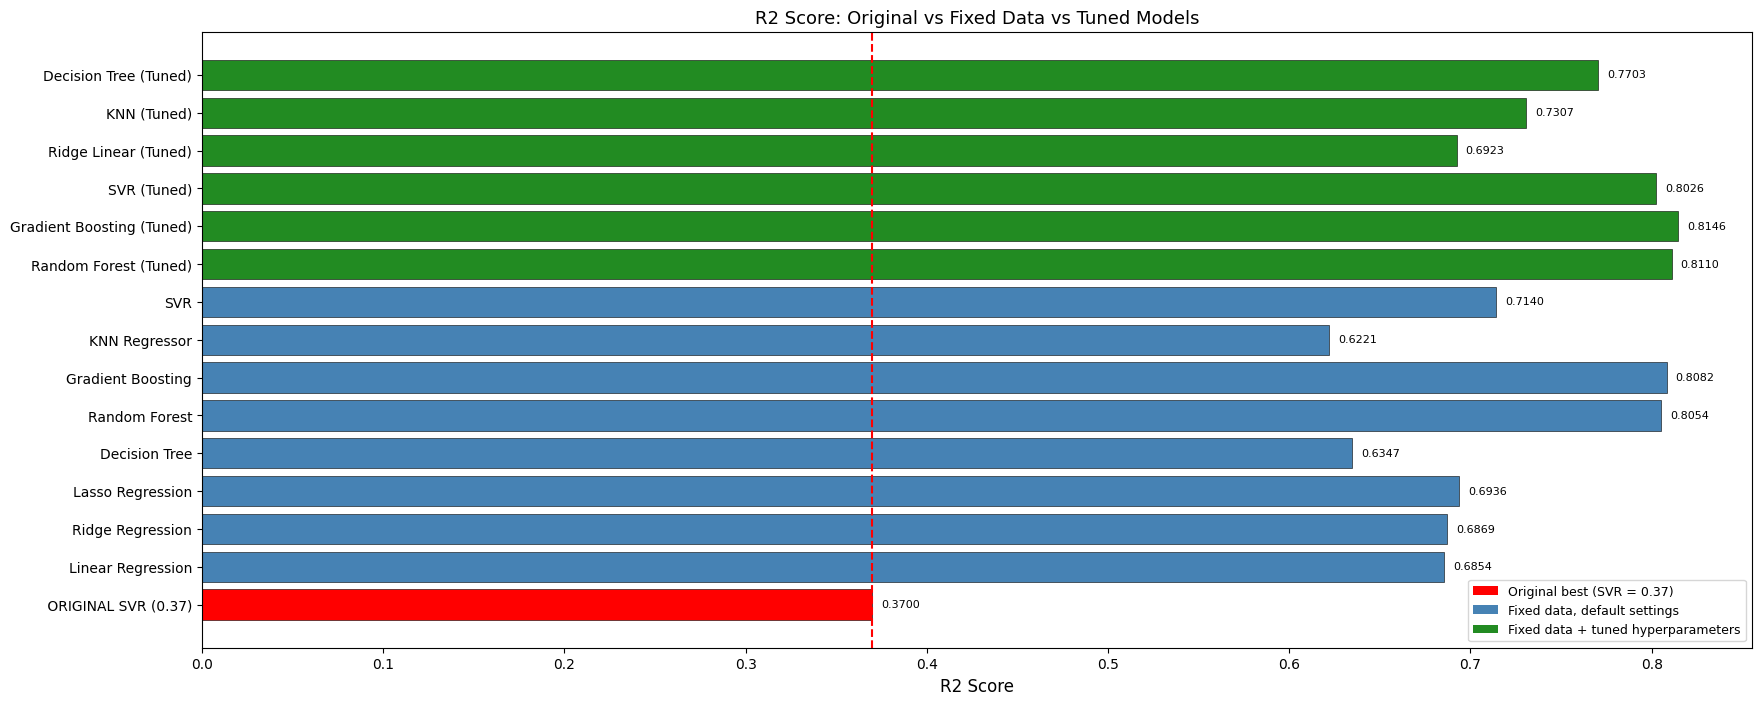

In [44]:
# STEP 14 - plot: R2 comparison (original vs baseline vs tuned)
print("\t\t\tPlotting R2 comparison \n")
fig, ax = plt.subplots(figsize=(20, 8))
names  = [' ORIGINAL SVR (0.37)'] + \
         [r['Model'] for r in baseline_results] + \
         [r['Model'] for r in tuned_results]
r2vals = [0.37] + \
         [r['R2'] for r in baseline_results] + \
         [r['R2'] for r in tuned_results]
colors = ['red'] + ['steelblue'] * len(baseline_results) + ['forestgreen'] * len(tuned_results)

ax.barh(names, r2vals, color=colors, edgecolor='black', linewidth=0.4)
for i, v in enumerate(r2vals):
    ax.text(max(v + 0.005, 0.01), i, f"{v:.4f}", va='center', fontsize=8)
ax.axvline(x=0.37, color='red', linestyle='--', lw=1.5, label='Original best = 0.37')
ax.set_xlabel("R2 Score", fontsize=12)
ax.set_title("R2 Score: Original vs Fixed Data vs Tuned Models", fontsize=13)
ax.legend(handles=[Patch(facecolor='red',label='Original best (SVR = 0.37)'), Patch(facecolor='steelblue', label='Fixed data, default settings'),
Patch(facecolor='forestgreen',label='Fixed data + tuned hyperparameters'),
], loc='lower right', fontsize=9)

			 Actual vs predicted 



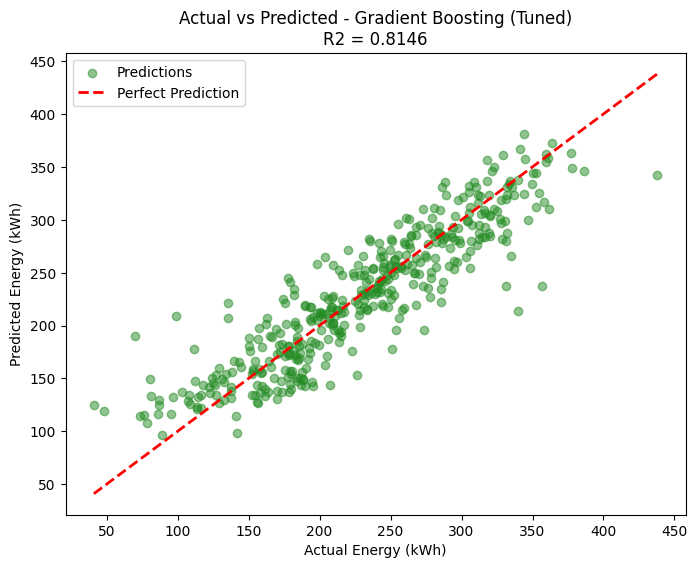

In [45]:
# STEP 15 - actual vs predicted for best tuned model
print("\t\t\t Actual vs predicted \n")
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='forestgreen', label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Energy (kWh)")
plt.ylabel("Predicted Energy (kWh)")
plt.title(f"Actual vs Predicted - {best_name}\nR2 = {best_r2}")
plt.legend()

			 Residuals plot 



Text(0.5, 1.0, 'Residuals Distribution (ideal = bell curve at 0)')

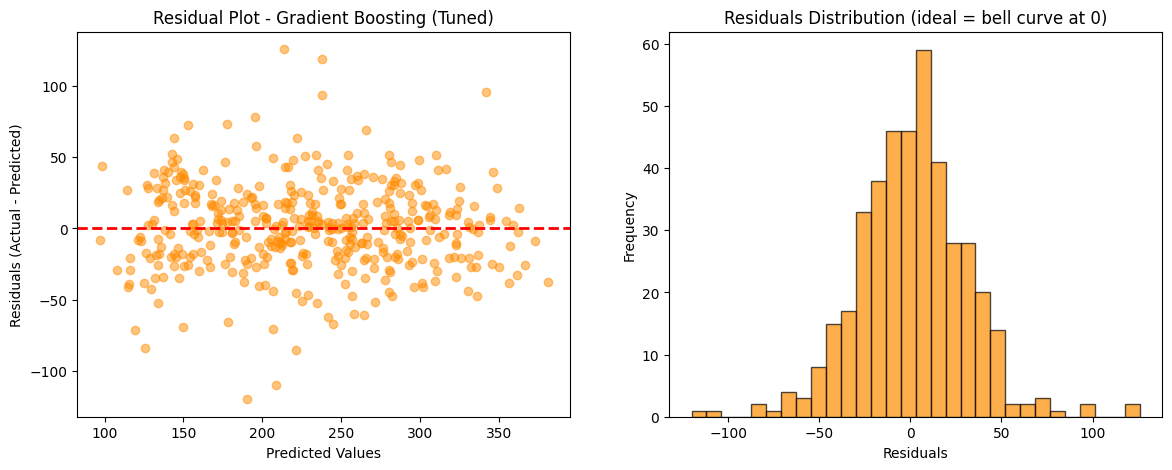

In [46]:
# STEP 16 - residuals plot
print("\t\t\t Residuals plot \n")
residuals = y_test.values - y_pred_best
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_best, residuals, alpha=0.5, color='darkorange')
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals (Actual - Predicted)")
axes[0].set_title(f"Residual Plot - {best_name}")
axes[1].hist(residuals, bins=30, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Residuals")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residuals Distribution (ideal = bell curve at 0)")

			Feature importance 

top 10 features:
             Feature  Importance
Students_x_Appliance    0.507123
      CO2_x_Students    0.289000
       CO2_Level_ppm    0.049169
     Appliance_Usage    0.041070
    Students_Present    0.032285
       Temperature_C    0.028735
     Occupancy_Level    0.012580
 Solar_Radiation_Wm2    0.007833
   Lighting_Usage_kW    0.003707
    Humidity_Percent    0.003373


Text(0.5, 1.0, 'Top 15 Feature Importances - Gradient Boosting (Tuned)')

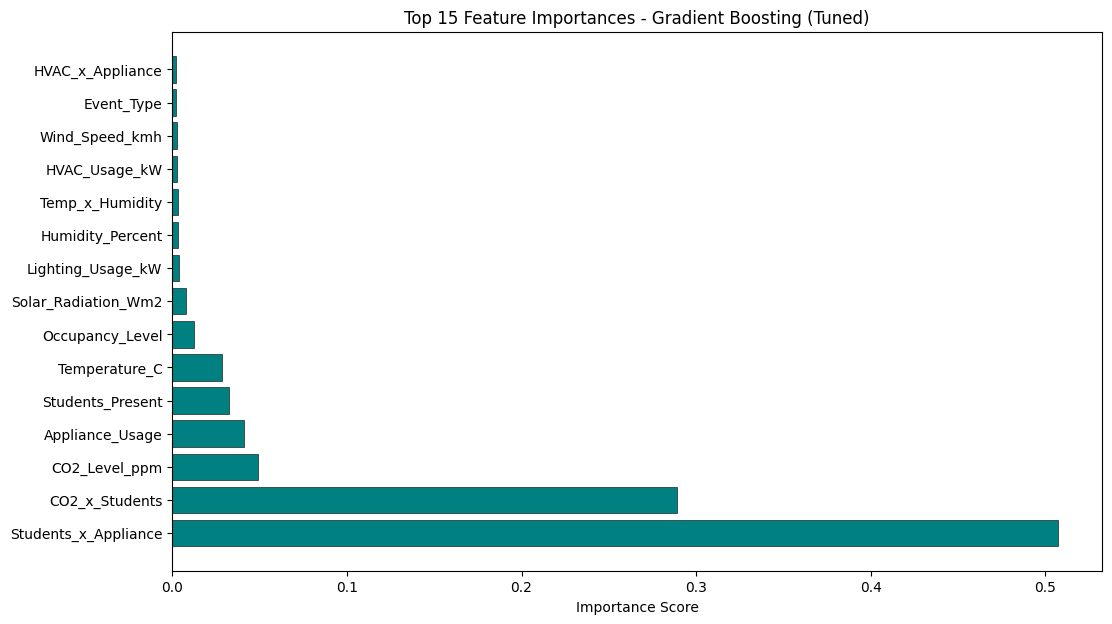

In [47]:
# STEP 17 - feature importance
print("\t\t\tFeature importance \n")

importances = best_model.feature_importances_
imp_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : importances
}).sort_values('Importance', ascending=False)

print("top 10 features:")
print(imp_df.head(10).to_string(index=False))

plt.figure(figsize=(12, 7))
plt.barh(imp_df['Feature'][:15], imp_df['Importance'][:15],color='teal', edgecolor='black', linewidth=0.4)
plt.xlabel("Importance Score")
plt.title(f"Top 15 Feature Importances - {best_name}")

			Cross validation box plot 



Text(0.5, 1.0, '5-Fold CV R2 Distribution - Tuned Models')

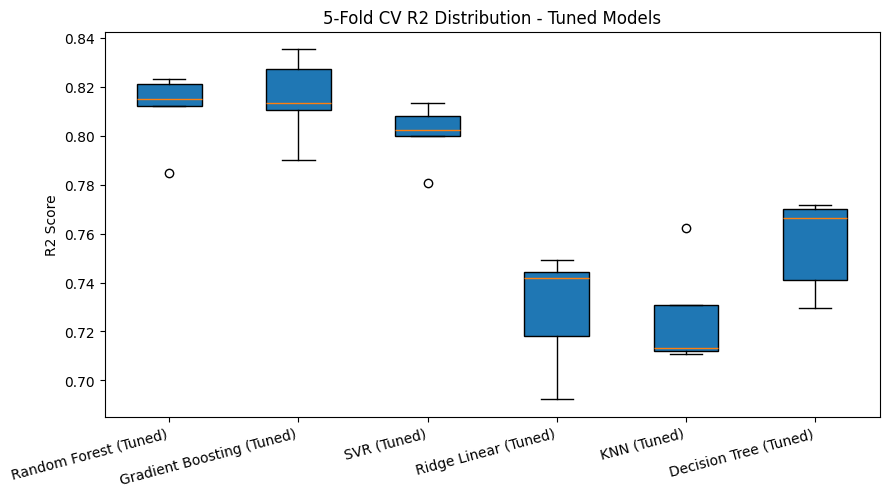

In [48]:
# STEP 18 - cross validation box plot for tuned models
print("\t\t\tCross validation box plot \n")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res = {}
for name, model in tuned_models.items():
    cv_res[name] = cross_val_score(model, X_scaled, y, cv=kfold, scoring='r2')

plt.figure(figsize=(10, 5))
plt.boxplot(cv_res.values(), labels=cv_res.keys(), patch_artist=True)
plt.xticks(rotation=15, ha='right')
plt.ylabel("R2 Score")
plt.title("5-Fold CV R2 Distribution - Tuned Models")

In [49]:
# FINAL SUMMARY
print("PROBLEMS THAT CAUSED LOW R2 = 0.37 AND HOW WE FIXED THEM:\n")
print(f'''FIX 1 - Median imputation (was dropna)
1051 -> {len(df)} (+{len(df)-1051} rows recovered)\n
    ''')
print("FIX 2 - Removed negative + extreme outlier target values \nRange was -189 to 2749, now 20 to 458 kWh \n")
print("FIX 3 - Used all 21 features (was 8) \n")
print("FIX 4 - Added 4 interaction features \nCO2 x Students, Temp x Humidity, HVAC x Appliance,Students x Appliance \n")
print("FIX 5 - GridSearchCV hyperparameter tuning \nTried all combinations to find optimal settings \n")
print(f"RESULT:")
print(f"Before : SVR  R2 = 0.37")
print(f"After  : {best_name}  R2 = {best_r2}")
print(f"Improvement : +{round((best_r2 - 0.37) * 100, 1)} percentage points")

PROBLEMS THAT CAUSED LOW R2 = 0.37 AND HOW WE FIXED THEM:

FIX 1 - Median imputation (was dropna)
1051 -> 2085 (+1034 rows recovered)

    
FIX 2 - Removed negative + extreme outlier target values 
Range was -189 to 2749, now 20 to 458 kWh 

FIX 3 - Used all 21 features (was 8) 

FIX 4 - Added 4 interaction features 
CO2 x Students, Temp x Humidity, HVAC x Appliance,Students x Appliance 

FIX 5 - GridSearchCV hyperparameter tuning 
Tried all combinations to find optimal settings 

RESULT:
Before : SVR  R2 = 0.37
After  : Gradient Boosting (Tuned)  R2 = 0.8146
Improvement : +44.5 percentage points


In [50]:
# EXPORT MODEL
'''
This saves everything needed to make predictions later:
    - the trained model
    - the StandardScaler
    - the LabelEncoders
    - the median values
    - the feature names
   '''
import joblib
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# create a folder to store all saved files neatly
os.makedirs("saved_model", exist_ok=True)

# 1. save best trained model
joblib.dump(best_model, "saved_model/best_model.pkl")
print("Model saved  --> saved_model/best_model.pkl\n")
print(f"   model type        : {type(best_model).__name__}")
print(f"   model R2 score    : {best_r2}")

Model saved  --> saved_model/best_model.pkl

   model type        : GradientBoostingRegressor
   model R2 score    : 0.8146


In [51]:
# 2. save the StandardScaler
joblib.dump(scaler, "saved_model/scaler.pkl")
print("Scaler saved--> saved_model/scaler.pkl")

Scaler saved--> saved_model/scaler.pkl


In [52]:
# 3. save the LabelEncoders
categorical_columns = [
    'Season', 'Building_Type', 'Weather_Condition', 'Occupancy_Level',
    'Shift', 'HVAC_Mode', 'Event_Type', 'Maintenance_Status'
]

# reload original data to re-fit encoders on string values
df_orig = pd.read_csv("institutional_energy(1).csv")
df_orig = df_orig.drop_duplicates().reset_index(drop=True)

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    le.fit(df_orig[col].astype(str))
    label_encoders[col] = le

joblib.dump(label_encoders, "saved_model/label_encoders.pkl")
print("Label encoders saved --> saved_model/label_encoders.pkl")
print()
for col, le in label_encoders.items():
    print(f"   {col}: {list(le.classes_)}")

Label encoders saved --> saved_model/label_encoders.pkl

   Season: ['Fall', 'Spring', 'Summer', 'Winter']
   Building_Type: ['Auditorium', 'Cafeteria', 'Classroom', 'Gymnasium', 'Laboratory', 'Labratory', 'Library', 'Office', 'cafeteria', 'nan']
   Weather_Condition: ['Cloudy', 'Foggy', 'Partly_Cloudy', 'RAINY', 'Rainy', 'Stormy', 'Sunny', 'Windy', 'nan', 'sunny']
   Occupancy_Level: ['Full', 'High', 'Low', 'Medium', 'nan']
   Shift: ['Afternoon', 'Evening', 'Morning', 'Night']
   HVAC_Mode: ['Auto', 'Cooling', 'Heating', 'Off', 'Ventilation', 'cooling', 'nan']
   Event_Type: ['EXAM', 'Exam', 'Holiday', 'No_Event', 'Regular_Class', 'Seminar', 'Sports_Event', 'Workshop']
   Maintenance_Status: ['Normal', 'Post_Maintenance', 'Scheduled_Check', 'Under_Maintenance', 'nan']


In [53]:
# 4. save ALL other info in ONE joblib file
numerical_columns = [
    'Time_of_Day', 'Students_Present', 'Temperature_C', 'Appliance_Usage',
    'Day_of_Week', 'Month', 'Humidity_Percent', 'Wind_Speed_kmh',
    'Solar_Radiation_Wm2', 'HVAC_Usage_kW', 'Lighting_Usage_kW',
    'Water_Usage_Liters', 'CO2_Level_ppm'
]
# calculate median of each numerical column from original data
df_num = df_orig[numerical_columns].copy()
for col in numerical_columns:
    df_num[col] = pd.to_numeric(df_num[col], errors='coerce')

medians = {}
for col in numerical_columns:
    medians[col] = float(df_num[col].median())
model_info = {
    "medians"            : medians,
    "feature_names"      : list(X.columns),
    "model_name"         : type(best_model).__name__,
    "best_r2_score"      : float(best_r2),
    "best_rmse"          : float(tuned_df.loc[bi, 'RMSE']),
    "best_mae"           : float(tuned_df.loc[bi, 'MAE']),
    "cv_r2_mean"         : float(tuned_df.loc[bi, 'CV R2']),
    "training_rows"      : int(X_train.shape[0]),
    "total_features"     : int(len(list(X.columns))),
    "numerical_columns"  : numerical_columns,
    "categorical_columns": categorical_columns
}

# save the whole dictionary as one file
joblib.dump(model_info, "saved_model/model_info.pkl")
print("Model_info saved --> saved_model/model_info.pkl\n")
print("Contains: medians, feature_names, model metadata \n")
print("   medians:")
for col, val in medians.items():
    print(f"     {col}: {round(val, 2)}")
print()
print("   feature names:", list(X.columns))

Model_info saved --> saved_model/model_info.pkl

Contains: medians, feature_names, model metadata 

   medians:
     Time_of_Day: 12.0
     Students_Present: 281.5
     Temperature_C: 27.91
     Appliance_Usage: 30.0
     Day_of_Week: 4.0
     Month: 7.0
     Humidity_Percent: 62.5
     Wind_Speed_kmh: 25.25
     Solar_Radiation_Wm2: 172.3
     HVAC_Usage_kW: 15.02
     Lighting_Usage_kW: 7.75
     Water_Usage_Liters: 1514.45
     CO2_Level_ppm: 540.5

   feature names: ['Time_of_Day', 'Students_Present', 'Temperature_C', 'Appliance_Usage', 'Day_of_Week', 'Month', 'Season', 'Building_Type', 'Weather_Condition', 'Occupancy_Level', 'Shift', 'HVAC_Mode', 'Event_Type', 'Maintenance_Status', 'Humidity_Percent', 'Wind_Speed_kmh', 'Solar_Radiation_Wm2', 'HVAC_Usage_kW', 'Lighting_Usage_kW', 'Water_Usage_Liters', 'CO2_Level_ppm', 'CO2_x_Students', 'Temp_x_Humidity', 'HVAC_x_Appliance', 'Students_x_Appliance']


In [54]:
# FINAL CONFIRMATION
print("\t\tALL FILES SAVED SUCCESSFULLY IN saved_model/ FOLDER:\n")

for fname in os.listdir("saved_model"):
    fpath = f"saved_model/{fname}"
    size  = os.path.getsize(fpath)
    print(f"  {fname:35s} {size:>8} bytes")

		ALL FILES SAVED SUCCESSFULLY IN saved_model/ FOLDER:

  .ipynb_checkpoints                         0 bytes
  best_model.pkl                        256761 bytes
  label_encoders.pkl                      2587 bytes
  Model_Improve_Export.ipynb            427919 bytes
  model_info.pkl                          1161 bytes
  saved_model.pkl                       256761 bytes
  scaler.pkl                              1823 bytes
